In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

ENERGY_ROOT = "/Users/u7826985/Projects/Nvidia/results/2026_03_08_wholeTests/energy"
DNA_FOLDER  = "100taxa_diff_trees_1M_sites"
AA_FOLDER   = "100taxa_diff_trees_1M_sites_AA"

# Colours consistent with the other notebooks
IMPL_COLORS = {
    'OPENACC': '#E65100',  # deep orange  (= IQ-TREE GPU)
    'VANILA':  '#1565C0',  # blue         (= IQ-TREE CPU)
}
IMPL_LABELS = {'OPENACC': 'IQ-TREE OpenACC (GPU)', 'VANILA': 'IQ-TREE Vanilla (CPU)'}

In [2]:
# ── Regex patterns for the Arm perf-report text format ──
_RE_TOTAL_TIME    = re.compile(r"Total time:\s+(\d+)\s+seconds?")
_RE_TOTAL_ENERGY  = re.compile(r"A breakdown of how the ([\d.]+) Wh was used")
_RE_CPU_ENERGY    = re.compile(r"CPU:\s+([\d.]+)%")
_RE_ACCEL_ENERGY  = re.compile(r"Accelerators:\s+([\d.]+)%")
_RE_PEAK_POWER    = re.compile(r"Peak node power:\s+([\d.]+)\s+W")
_RE_COMPUTE       = re.compile(r"Compute:\s+([\d.]+)%\s+\(([\d.]+)s\)")
_RE_IO            = re.compile(r"I/O:\s+([\d.]+)%\s+\(([\d.]+)s\)")
_RE_GPU_UTIL      = re.compile(r"GPU utilization:\s+([\d.]+)%")
_RE_GPU_MEM_MEAN  = re.compile(r"Mean GPU memory usage:\s+([\d.]+)%")
_RE_GPU_MEM_PEAK  = re.compile(r"Peak GPU memory usage:\s+([\d.]+)%")
_RE_PROC_MEM_MEAN = re.compile(r"Mean process memory usage:\s+([\d.]+)\s+GiB")
_RE_PROC_MEM_PEAK = re.compile(r"Peak process memory usage:\s+([\d.]+)\s+GiB")
_RE_NODE_MEM_PEAK = re.compile(r"Peak node memory usage:\s+([\d.]+)%")
_RE_MEM_ACC       = re.compile(r"Memory accesses:\s+([\d.]+)%")
_RE_SCALAR_OPS    = re.compile(r"Scalar numeric ops:\s+([\d.]+)%")
_RE_VECTOR_OPS    = re.compile(r"Vector numeric ops:\s+([\d.]+)%")


def _flt(m, group=1):
    return float(m.group(group)) if m else float('nan')


def parse_perf_report(filepath, implementation, tree, run, dataset_type):
    """Parse one Arm perf-report .txt file; return a dict of metrics."""
    with open(filepath, 'r') as f:
        text = f.read()

    total_time   = _flt(_RE_TOTAL_TIME.search(text))
    total_energy = _flt(_RE_TOTAL_ENERGY.search(text))
    cpu_e_pct    = _flt(_RE_CPU_ENERGY.search(text))
    accel_e_pct  = _flt(_RE_ACCEL_ENERGY.search(text))   # NaN for VANILA
    peak_power   = _flt(_RE_PEAK_POWER.search(text))

    m_comp = _RE_COMPUTE.search(text)
    compute_pct  = _flt(m_comp, 1) if m_comp else float('nan')
    compute_s    = _flt(m_comp, 2) if m_comp else float('nan')

    m_io = _RE_IO.search(text)
    io_pct = _flt(m_io, 1) if m_io else float('nan')
    io_s   = _flt(m_io, 2) if m_io else float('nan')

    return {
        'implementation':       implementation,
        'dataset_type':         dataset_type,
        'tree':                 tree,
        'run':                  run,
        'total_time_s':         total_time,
        'total_energy_wh':      total_energy,
        'cpu_energy_pct':       cpu_e_pct,
        'accel_energy_pct':     accel_e_pct,
        'peak_power_w':         peak_power,
        'compute_pct':          compute_pct,
        'compute_time_s':       compute_s,
        'io_pct':               io_pct,
        'io_time_s':            io_s,
        'gpu_util_pct':         _flt(_RE_GPU_UTIL.search(text)),
        'gpu_mem_mean_pct':     _flt(_RE_GPU_MEM_MEAN.search(text)),
        'gpu_mem_peak_pct':     _flt(_RE_GPU_MEM_PEAK.search(text)),
        'proc_mem_mean_gib':    _flt(_RE_PROC_MEM_MEAN.search(text)),
        'proc_mem_peak_gib':    _flt(_RE_PROC_MEM_PEAK.search(text)),
        'node_mem_peak_pct':    _flt(_RE_NODE_MEM_PEAK.search(text)),
        'mem_accesses_pct':     _flt(_RE_MEM_ACC.search(text)),
        'scalar_ops_pct':       _flt(_RE_SCALAR_OPS.search(text)),
        'vector_ops_pct':       _flt(_RE_VECTOR_OPS.search(text)),
    }


def collect_energy_data(energy_root, folder, dataset_type):
    """Walk all tree subdirs, parse every perf_report .txt, return DataFrame."""
    records = []
    base    = os.path.join(energy_root, folder)
    # Match: perf_report_..._OPENACC_runN_... or perf_report_..._VANILA_runN_...
    fname_re = re.compile(
        r'perf_report_.*?_(OPENACC|VANILA)_run(\d+)_tree(\d+)_.*\.txt$',
        re.IGNORECASE
    )
    for i in range(1, 11):
        tree_dir = os.path.join(base, f"tree_{i}")
        if not os.path.isdir(tree_dir):
            continue
        for fname in os.listdir(tree_dir):
            m = fname_re.search(fname)
            if not m:
                continue
            impl = m.group(1).upper()
            run  = int(m.group(2))
            tree = f"tree_{i}"
            fp   = os.path.join(tree_dir, fname)
            try:
                rec = parse_perf_report(fp, impl, tree, run, dataset_type)
                records.append(rec)
            except Exception as e:
                print(f"  WARN: failed to parse {fname}: {e}")

    df = pd.DataFrame(records)
    print(f"{dataset_type}: {len(df)} records  |  implementations: {sorted(df['implementation'].unique())}")
    print(df.groupby(['implementation', 'tree']).size().unstack(fill_value=0).to_string())
    return df

In [3]:
df_dna = collect_energy_data(ENERGY_ROOT, DNA_FOLDER, 'DNA')
df_aa  = collect_energy_data(ENERGY_ROOT, AA_FOLDER,  'AA')
df_all = pd.concat([df_dna, df_aa], ignore_index=True)
print(f"\nTotal records: {len(df_all)}")

DNA: 200 records  |  implementations: ['OPENACC', 'VANILA']
tree            tree_1  tree_10  tree_2  tree_3  tree_4  tree_5  tree_6  tree_7  tree_8  tree_9
implementation                                                                                 
OPENACC             10       10      10      10      10      10      10      10      10      10
VANILA              10       10      10      10      10      10      10      10      10      10
AA: 200 records  |  implementations: ['OPENACC', 'VANILA']
tree            tree_1  tree_10  tree_2  tree_3  tree_4  tree_5  tree_6  tree_7  tree_8  tree_9
implementation                                                                                 
OPENACC             10       10      10      10      10      10      10      10      10      10
VANILA              10       10      10      10      10      10      10      10      10      10

Total records: 400


---
## 1 · Summary Statistics

In [4]:
METRICS = ['total_energy_wh', 'total_time_s', 'cpu_energy_pct', 'accel_energy_pct',
           'gpu_util_pct', 'gpu_mem_peak_pct', 'proc_mem_peak_gib']

for dtype, df in [('DNA', df_dna), ('AA', df_aa)]:
    print(f"\n{'='*60}")
    print(f"  {dtype} Dataset — mean ± std per implementation")
    print('='*60)
    tbl = df.groupby('implementation')[METRICS].agg(['mean', 'std'])
    tbl.columns = [f"{m}_{s}" for m, s in tbl.columns]
    display(tbl.T.style.format("{:.3f}"))


  DNA Dataset — mean ± std per implementation


implementation,OPENACC,VANILA
total_energy_wh_mean,1.098,1.483
total_energy_wh_std,0.212,0.436
total_time_s_mean,18.840,18.460
total_time_s_std,7.440,1.579
cpu_energy_pct_mean,72.144,100.000
cpu_energy_pct_std,5.915,0.000
accel_energy_pct_mean,27.856,nan
accel_energy_pct_std,5.915,nan
gpu_util_pct_mean,0.518,nan
gpu_util_pct_std,0.101,nan



  AA Dataset — mean ± std per implementation


implementation,OPENACC,VANILA
total_energy_wh_mean,1.256,1.669
total_energy_wh_std,0.257,0.788
total_time_s_mean,21.090,29.860
total_time_s_std,8.357,0.667
cpu_energy_pct_mean,71.676,100.000
cpu_energy_pct_std,5.711,0.000
accel_energy_pct_mean,28.324,nan
accel_energy_pct_std,5.711,nan
gpu_util_pct_mean,1.667,nan
gpu_util_pct_std,0.210,nan


---
## 2 · Total Energy Consumption (Wh) per Tree

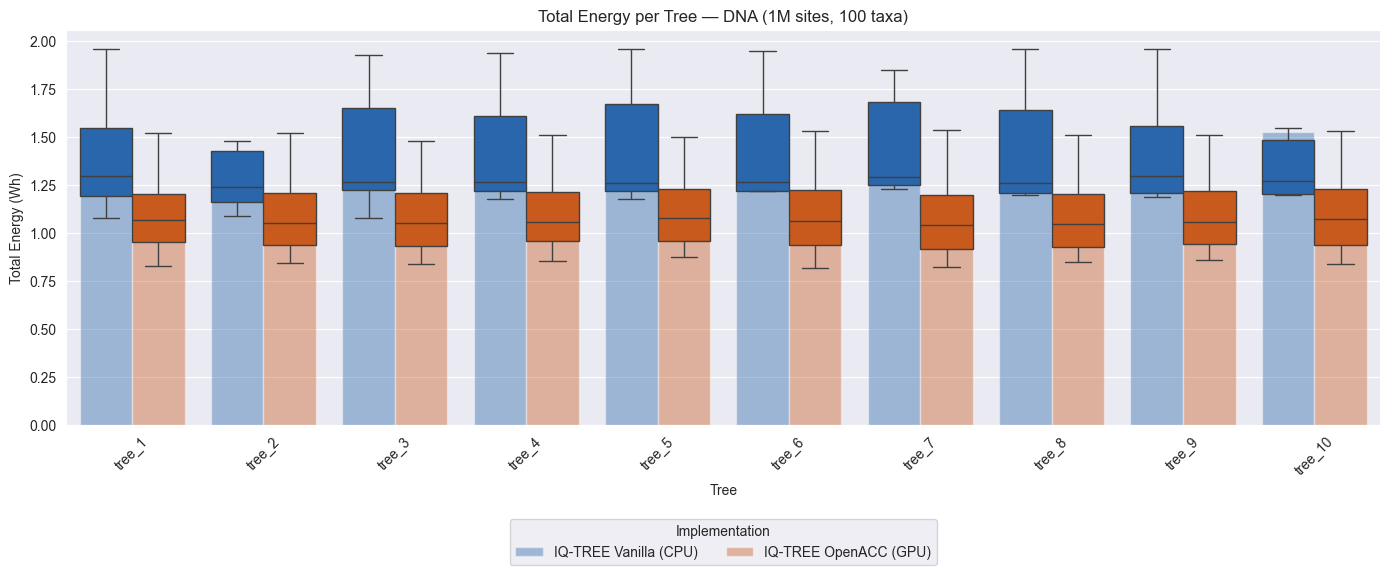

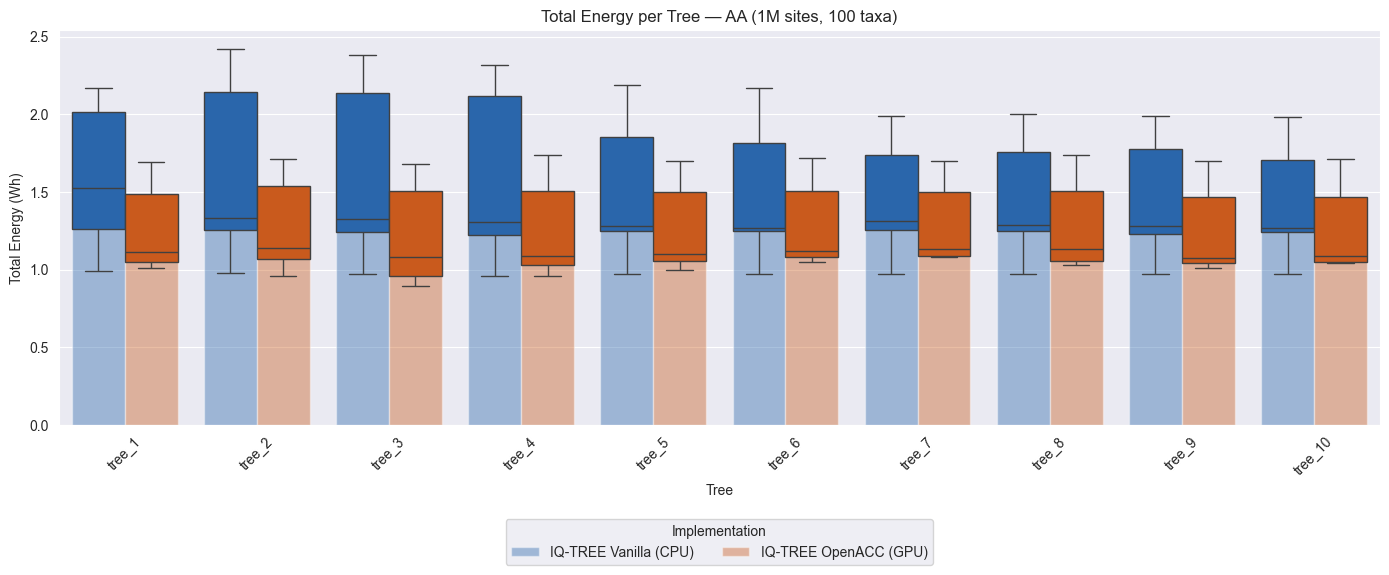

In [5]:
cwd = os.getcwd()

def _natural_order(trees):
    return sorted(trees, key=lambda t: int(re.search(r'(\d+)', t).group(1)))

def plot_energy_bar_box(df, title, path=""):
    """Bar (mean) + boxplot overlay per tree, split by implementation."""
    implementations = ['VANILA', 'OPENACC']
    palette = {impl: IMPL_COLORS[impl] for impl in implementations}
    tree_order = _natural_order(df['tree'].unique())

    fig, ax = plt.subplots(figsize=(14, 6))

    sns.barplot(data=df, x='tree', y='total_energy_wh', hue='implementation',
                order=tree_order, hue_order=implementations,
                estimator='mean', errorbar=None, alpha=0.4,
                dodge=True, palette=palette, ax=ax)

    sns.boxplot(data=df, x='tree', y='total_energy_wh', hue='implementation',
                order=tree_order, hue_order=implementations,
                showfliers=False, linewidth=1,
                palette=palette, ax=ax)

    ax.set_title(title)
    ax.set_xlabel("Tree")
    ax.set_ylabel("Total Energy (Wh)")
    ax.tick_params(axis='x', rotation=45)

    handles, labels = ax.get_legend_handles_labels()
    n = len(implementations)
    ax.legend(handles[:n], [IMPL_LABELS[l] for l in labels[:n]],
              title="Implementation",
              bbox_to_anchor=(0.5, -0.22), loc='upper center', ncol=n)

    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()


plot_energy_bar_box(df_dna, "Total Energy per Tree — DNA (1M sites, 100 taxa)",
                    path=f"{cwd}/energy_total_dna.png")
plot_energy_bar_box(df_aa,  "Total Energy per Tree — AA (1M sites, 100 taxa)",
                    path=f"{cwd}/energy_total_aa.png")

### 2b · DNA vs AA side-by-side

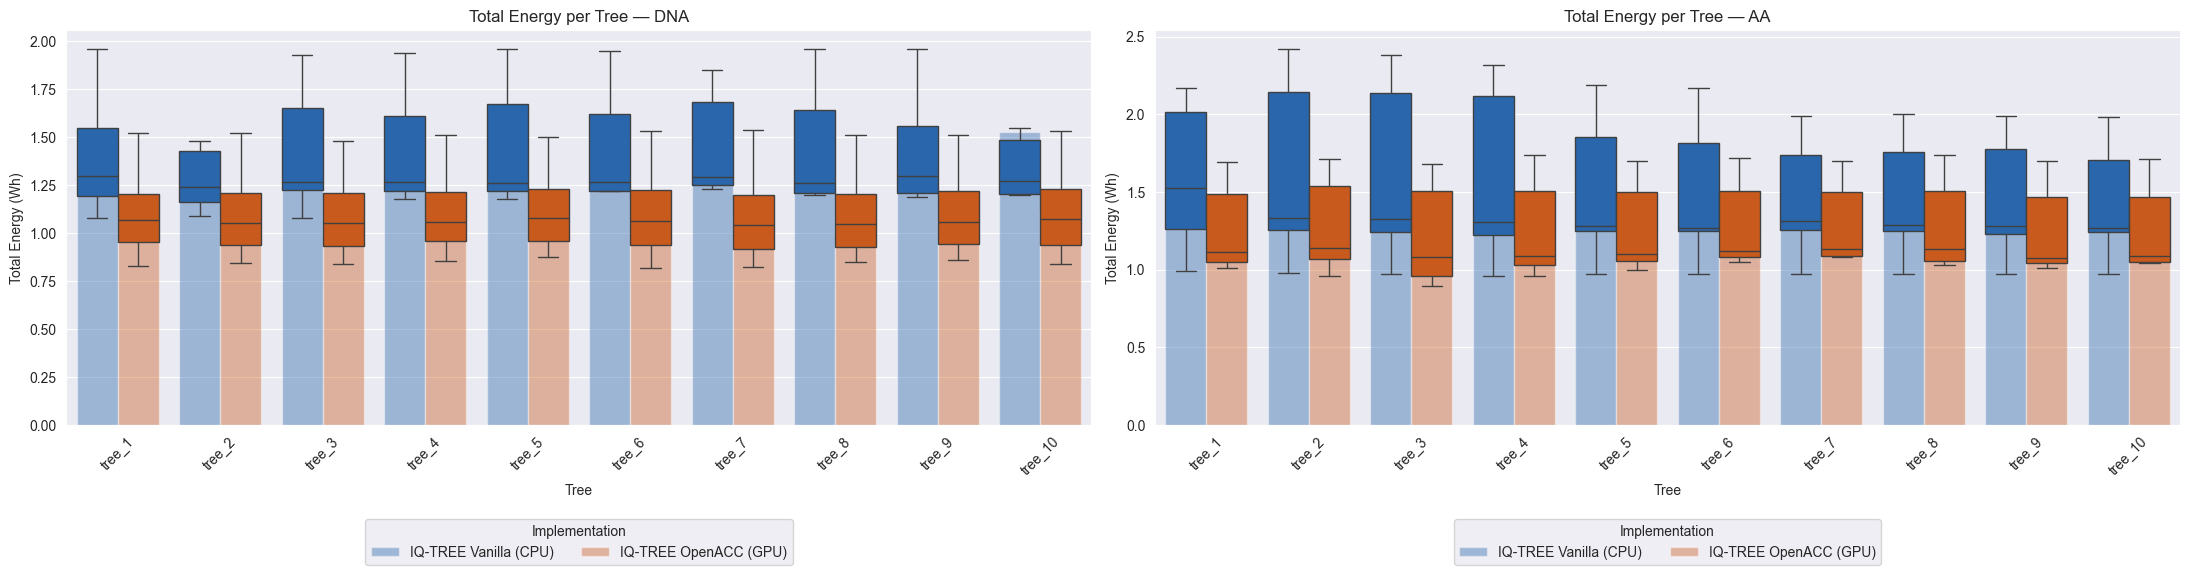

In [6]:
def plot_energy_sidebyside(df_dna, df_aa, path=""):
    implementations = ['VANILA', 'OPENACC']
    palette = {impl: IMPL_COLORS[impl] for impl in implementations}
    tree_order = _natural_order(df_dna['tree'].unique())

    fig, axes = plt.subplots(1, 2, figsize=(22, 6), sharey=False)

    for ax, df, label in zip(axes, [df_dna, df_aa], ['DNA', 'AA']):
        sns.barplot(data=df, x='tree', y='total_energy_wh', hue='implementation',
                    order=tree_order, hue_order=implementations,
                    estimator='mean', errorbar=None, alpha=0.4,
                    dodge=True, palette=palette, ax=ax)
        sns.boxplot(data=df, x='tree', y='total_energy_wh', hue='implementation',
                    order=tree_order, hue_order=implementations,
                    showfliers=False, linewidth=1, palette=palette, ax=ax)

        ax.set_title(f"Total Energy per Tree — {label}")
        ax.set_xlabel("Tree")
        ax.set_ylabel("Total Energy (Wh)")
        ax.tick_params(axis='x', rotation=45)

        handles, labels_ = ax.get_legend_handles_labels()
        n = len(implementations)
        ax.legend(handles[:n], [IMPL_LABELS[l] for l in labels_[:n]],
                  title="Implementation",
                  bbox_to_anchor=(0.5, -0.22), loc='upper center', ncol=n)

    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()


plot_energy_sidebyside(df_dna, df_aa,
                       path=f"{cwd}/energy_total_sidebyside.png")

---
## 3 · Execution Time (s) per Tree

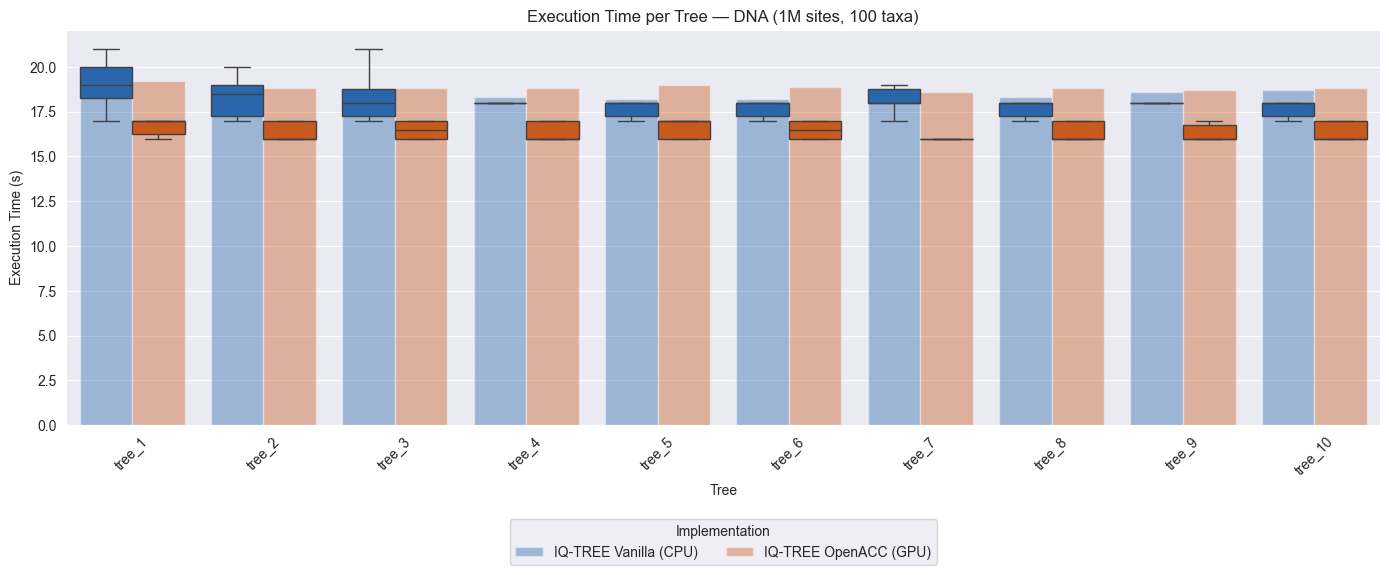

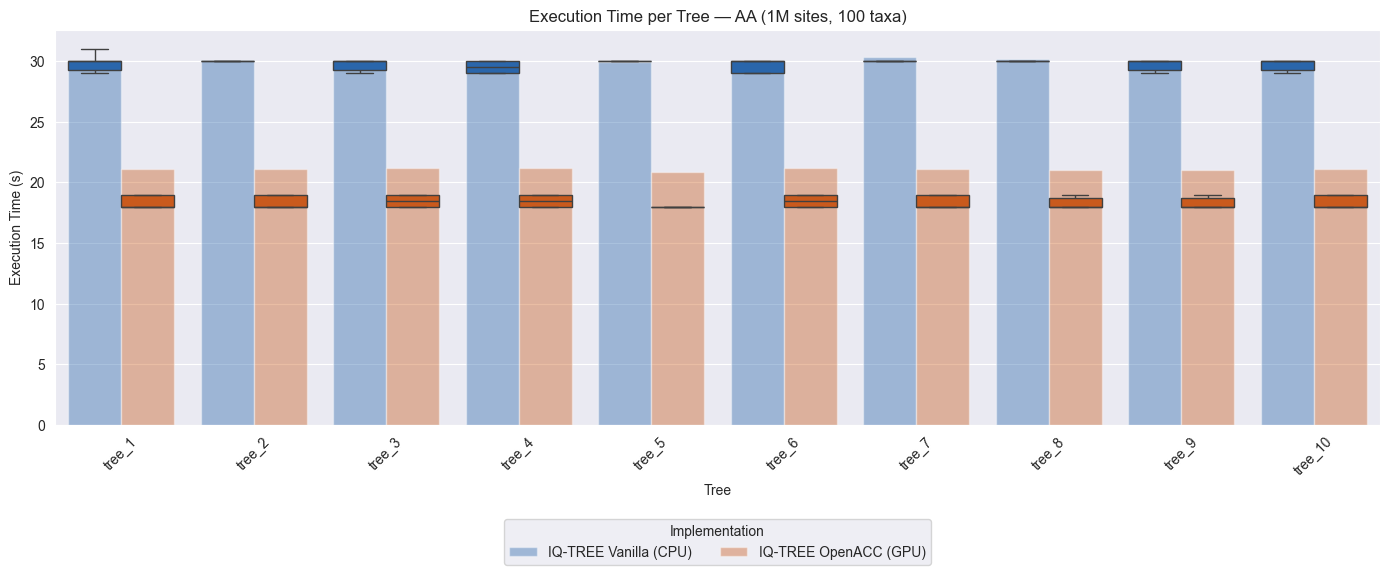

In [7]:
def plot_runtime_bar_box(df, title, path=""):
    implementations = ['VANILA', 'OPENACC']
    palette = {impl: IMPL_COLORS[impl] for impl in implementations}
    tree_order = _natural_order(df['tree'].unique())

    fig, ax = plt.subplots(figsize=(14, 6))

    sns.barplot(data=df, x='tree', y='total_time_s', hue='implementation',
                order=tree_order, hue_order=implementations,
                estimator='mean', errorbar=None, alpha=0.4,
                dodge=True, palette=palette, ax=ax)
    sns.boxplot(data=df, x='tree', y='total_time_s', hue='implementation',
                order=tree_order, hue_order=implementations,
                showfliers=False, linewidth=1, palette=palette, ax=ax)

    ax.set_title(title)
    ax.set_xlabel("Tree")
    ax.set_ylabel("Execution Time (s)")
    ax.tick_params(axis='x', rotation=45)

    handles, labels = ax.get_legend_handles_labels()
    n = len(implementations)
    ax.legend(handles[:n], [IMPL_LABELS[l] for l in labels[:n]],
              title="Implementation",
              bbox_to_anchor=(0.5, -0.22), loc='upper center', ncol=n)

    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()


plot_runtime_bar_box(df_dna, "Execution Time per Tree — DNA (1M sites, 100 taxa)",
                     path=f"{cwd}/runtime_dna.png")
plot_runtime_bar_box(df_aa,  "Execution Time per Tree — AA (1M sites, 100 taxa)",
                     path=f"{cwd}/runtime_aa.png")

---
## 4 · CPU vs Accelerator Energy Split (OpenACC only)
VANILA runs have no accelerator energy; the GPU contribution is visible for OpenACC only.

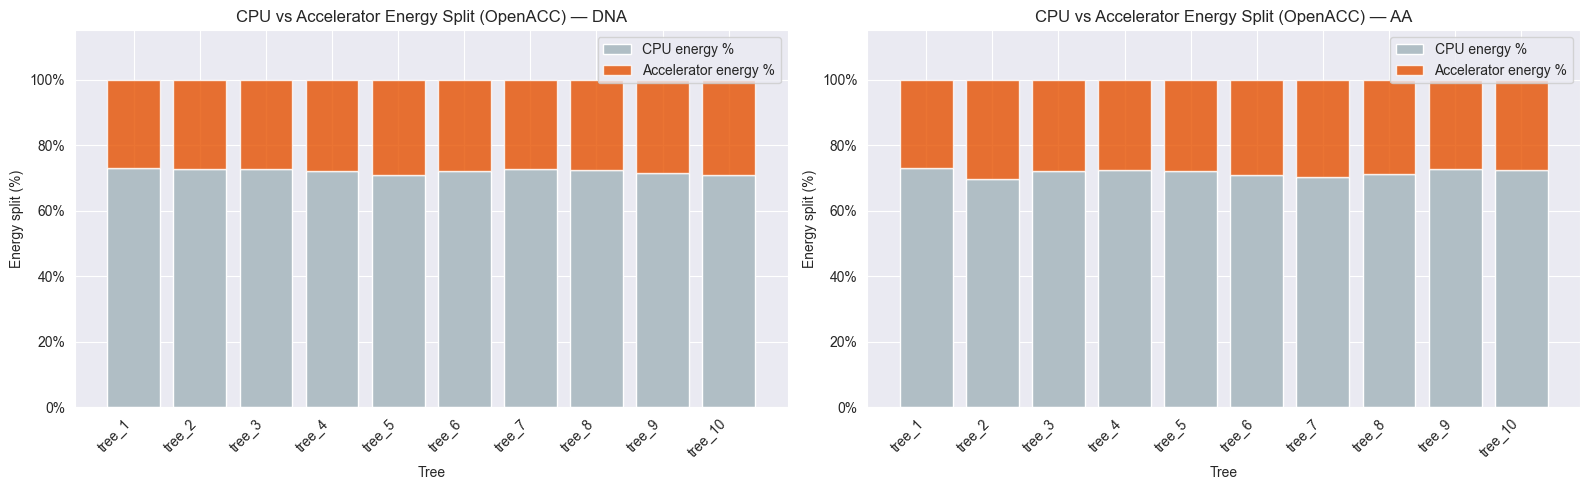

In [8]:
def plot_energy_split(df_dna, df_aa, path=""):
    """Stacked bar: CPU% vs Accelerator% energy for OpenACC runs."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, df, label in zip(axes, [df_dna, df_aa], ['DNA', 'AA']):
        odf = df[df['implementation'] == 'OPENACC'].copy()
        tree_order = _natural_order(odf['tree'].unique())
        grp = odf.groupby('tree')[['cpu_energy_pct', 'accel_energy_pct']].mean().reindex(tree_order)

        x = np.arange(len(tree_order))
        b1 = ax.bar(x, grp['cpu_energy_pct'],      color='#B0BEC5', label='CPU energy %')
        b2 = ax.bar(x, grp['accel_energy_pct'],
                    bottom=grp['cpu_energy_pct'],   color=IMPL_COLORS['OPENACC'],
                    alpha=0.8, label='Accelerator energy %')

        ax.set_xticks(x)
        ax.set_xticklabels(tree_order, rotation=45, ha='right')
        ax.set_ylim(0, 115)
        ax.set_ylabel("Energy split (%)")
        ax.set_xlabel("Tree")
        ax.set_title(f"CPU vs Accelerator Energy Split (OpenACC) — {label}")
        ax.legend(loc='upper right')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter())

    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()


plot_energy_split(df_dna, df_aa, path=f"{cwd}/energy_split_openacc.png")

---
## 5 · GPU Utilization & Memory (OpenACC only)

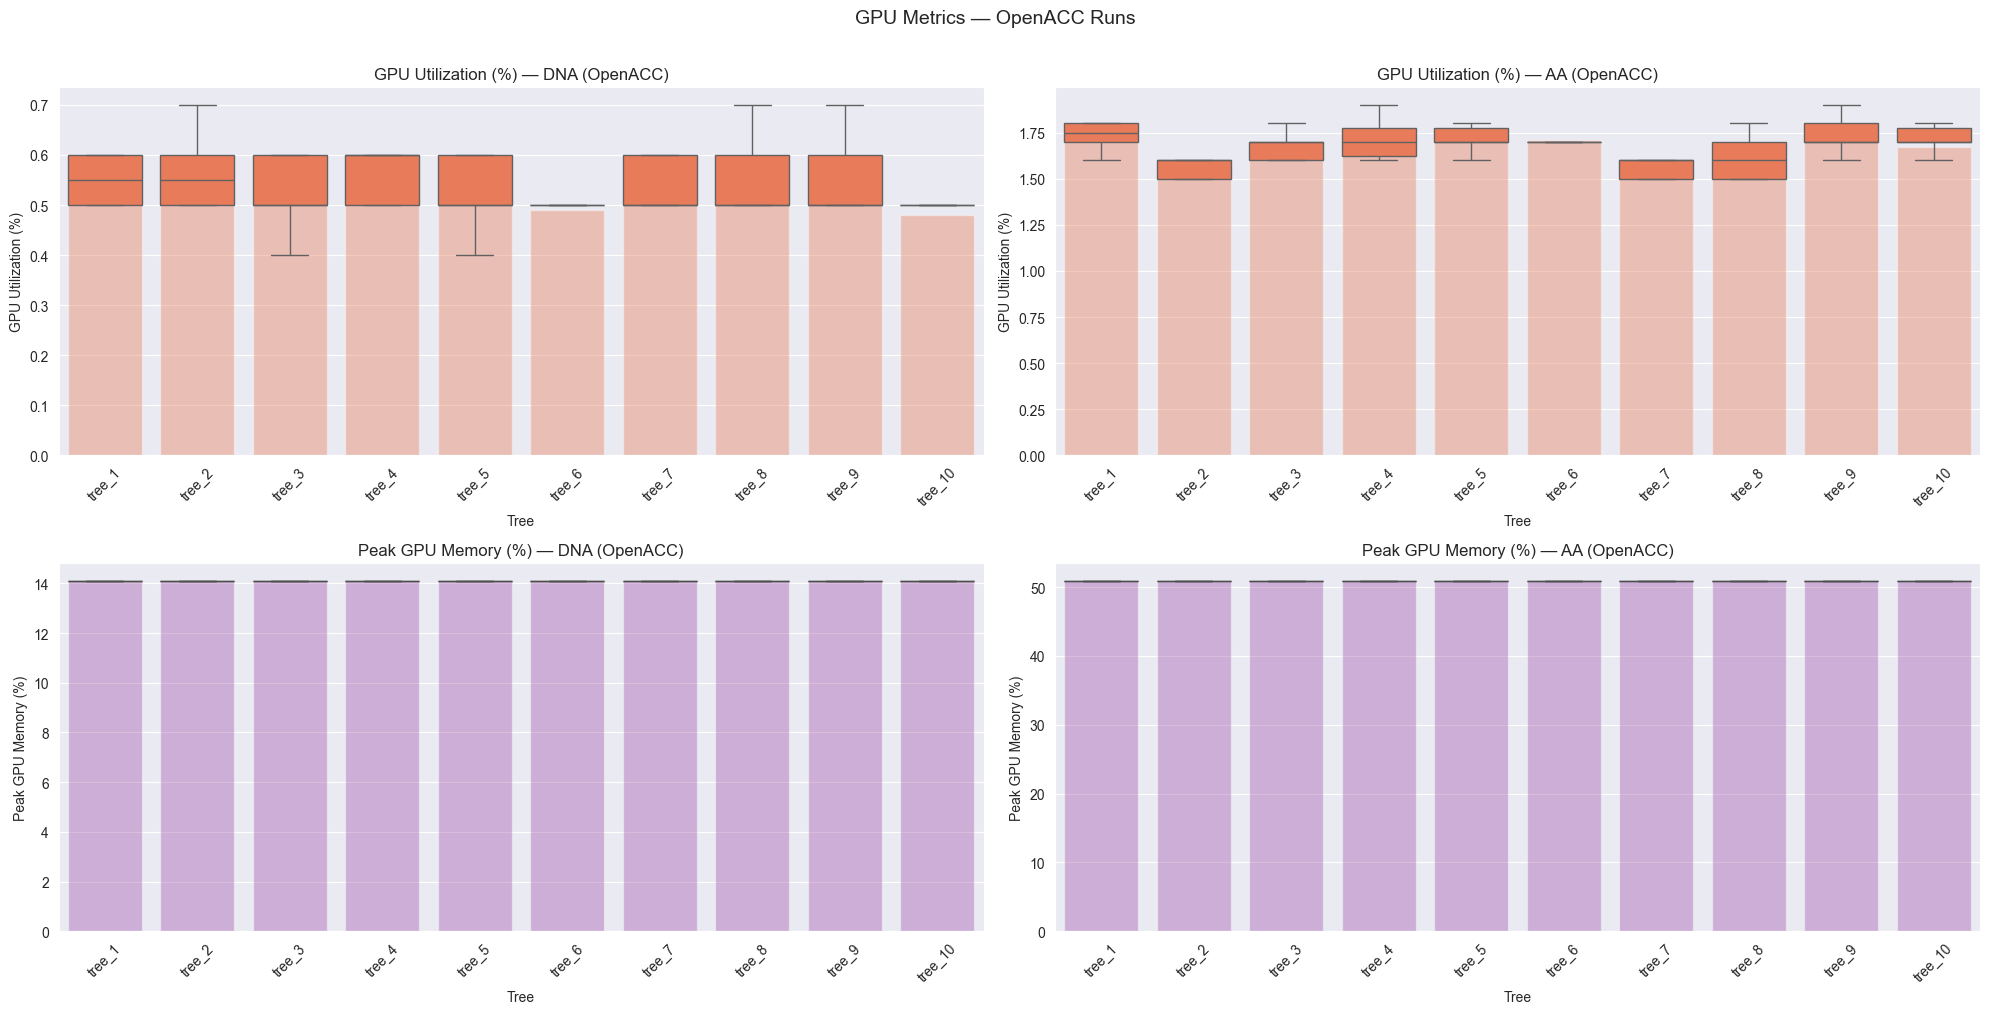

In [9]:
def plot_gpu_metrics(df_dna, df_aa, path=""):
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))

    METRICS_GPU = [
        ('gpu_util_pct',     'GPU Utilization (%)',       '#FF7043'),
        ('gpu_mem_peak_pct', 'Peak GPU Memory (%)',        '#AB47BC'),
        ('gpu_mem_mean_pct', 'Mean GPU Memory (%)',        '#7E57C2'),
    ]

    tree_order = _natural_order(df_dna['tree'].unique())

    for col_idx, (metric, ylabel, color) in enumerate(METRICS_GPU[:2]):
        for row_idx, (df, label) in enumerate([(df_dna, 'DNA'), (df_aa, 'AA')]):
            ax = axes[row_idx][col_idx]
            odf = df[df['implementation'] == 'OPENACC']
            sns.boxplot(data=odf, x='tree', y=metric, order=tree_order,
                        color=color, ax=ax, showfliers=False, linewidth=1)
            sns.barplot(data=odf, x='tree', y=metric, order=tree_order,
                        estimator='mean', errorbar=None, alpha=0.35, color=color, ax=ax)
            ax.set_title(f"{ylabel} — {label} (OpenACC)")
            ax.set_xlabel("Tree")
            ax.set_ylabel(ylabel)
            ax.tick_params(axis='x', rotation=45)

    # Third metric spans the bottom row
    metric, ylabel, color = METRICS_GPU[2]
    for col_idx, (df, label) in enumerate([(df_dna, 'DNA'), (df_aa, 'AA')]):
        ax = axes[1][col_idx]
        # Already filled above; use only row=1 slot that's free
    # Instead put mean GPU memory in the unused slots

    plt.suptitle("GPU Utilization & Memory Usage — OpenACC Runs", fontsize=14, y=1.01)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()


def plot_gpu_metrics_clean(df_dna, df_aa, path=""):
    """2-row × 2-col grid: (Util / Peak Mem) × (DNA / AA)."""
    metrics = [
        ('gpu_util_pct',     'GPU Utilization (%)',  '#FF7043'),
        ('gpu_mem_peak_pct', 'Peak GPU Memory (%)',  '#AB47BC'),
    ]
    datasets = [(df_dna, 'DNA'), (df_aa, 'AA')]
    tree_order = _natural_order(df_dna['tree'].unique())

    fig, axes = plt.subplots(len(metrics), len(datasets), figsize=(20, 10))

    for row, (metric, ylabel, color) in enumerate(metrics):
        for col, (df, label) in enumerate(datasets):
            ax = axes[row][col]
            odf = df[df['implementation'] == 'OPENACC']
            sns.barplot(data=odf, x='tree', y=metric, order=tree_order,
                        estimator='mean', errorbar=None, alpha=0.4, color=color, ax=ax)
            sns.boxplot(data=odf, x='tree', y=metric, order=tree_order,
                        color=color, ax=ax, showfliers=False, linewidth=1)
            ax.set_title(f"{ylabel} — {label} (OpenACC)")
            ax.set_xlabel("Tree")
            ax.set_ylabel(ylabel)
            ax.tick_params(axis='x', rotation=45)

    plt.suptitle("GPU Metrics — OpenACC Runs", fontsize=14, y=1.01)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()


plot_gpu_metrics_clean(df_dna, df_aa, path=f"{cwd}/gpu_metrics.png")

---
## 6 · Process Memory Usage

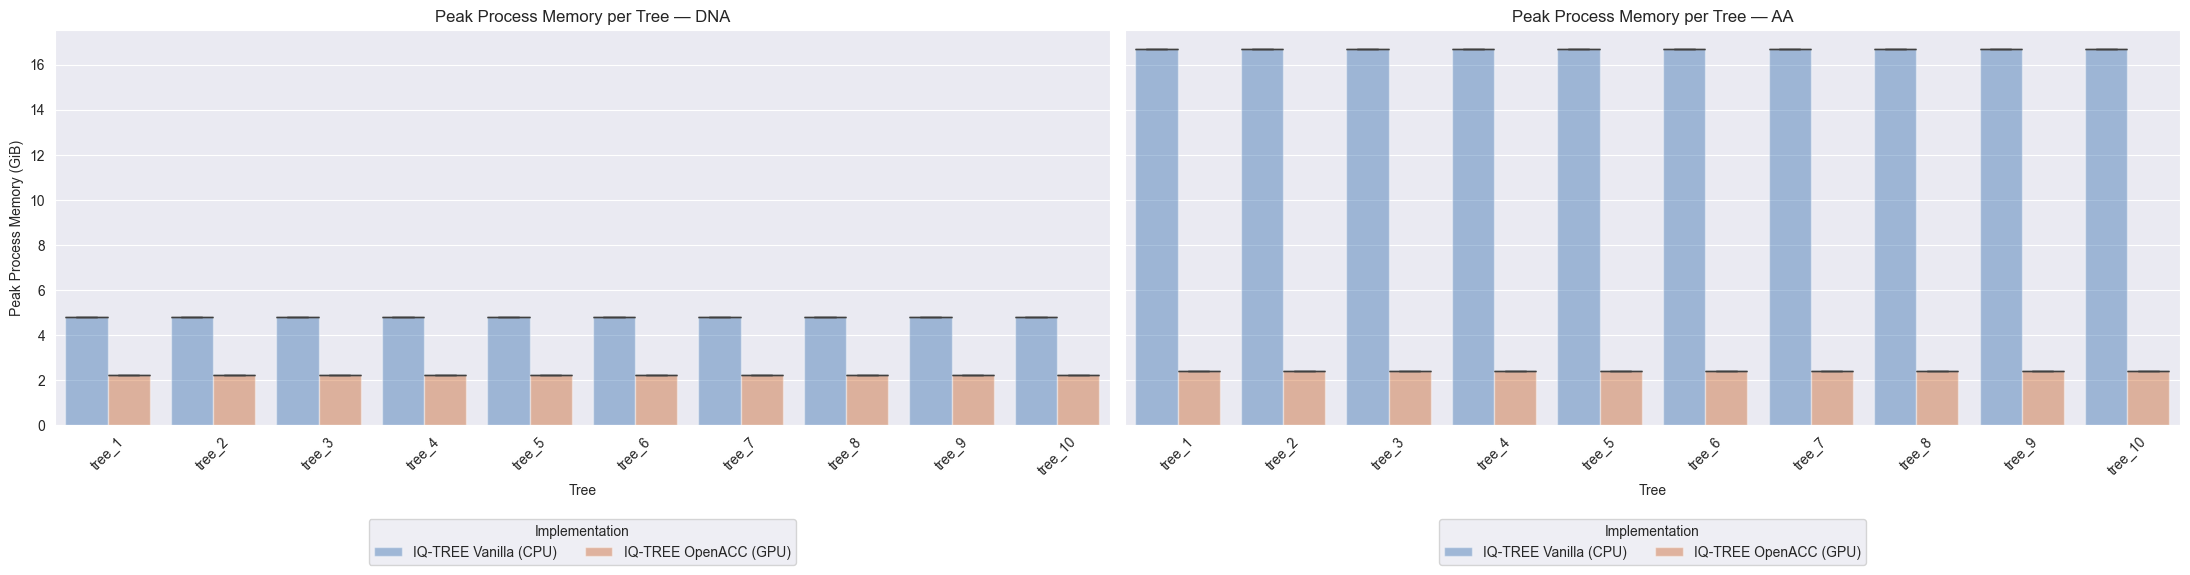

In [10]:
def plot_memory(df_dna, df_aa, metric, ylabel, title_prefix, path=""):
    implementations = ['VANILA', 'OPENACC']
    palette = {impl: IMPL_COLORS[impl] for impl in implementations}
    tree_order = _natural_order(df_dna['tree'].unique())

    fig, axes = plt.subplots(1, 2, figsize=(22, 6), sharey=True)

    for ax, df, label in zip(axes, [df_dna, df_aa], ['DNA', 'AA']):
        sns.barplot(data=df, x='tree', y=metric, hue='implementation',
                    order=tree_order, hue_order=implementations,
                    estimator='mean', errorbar=None, alpha=0.4,
                    dodge=True, palette=palette, ax=ax)
        sns.boxplot(data=df, x='tree', y=metric, hue='implementation',
                    order=tree_order, hue_order=implementations,
                    showfliers=False, linewidth=1, palette=palette, ax=ax)

        ax.set_title(f"{title_prefix} — {label}")
        ax.set_xlabel("Tree")
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=45)

        handles, labels_ = ax.get_legend_handles_labels()
        n = len(implementations)
        ax.legend(handles[:n], [IMPL_LABELS[l] for l in labels_[:n]],
                  title="Implementation",
                  bbox_to_anchor=(0.5, -0.22), loc='upper center', ncol=n)

    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()


plot_memory(df_dna, df_aa,
            metric='peak_process_memory_gib' if 'peak_process_memory_gib' in df_dna.columns
                   else 'proc_mem_peak_gib',
            ylabel='Peak Process Memory (GiB)',
            title_prefix='Peak Process Memory per Tree',
            path=f"{cwd}/memory_peak.png")

---
## 7 · Compute vs I/O Time Breakdown

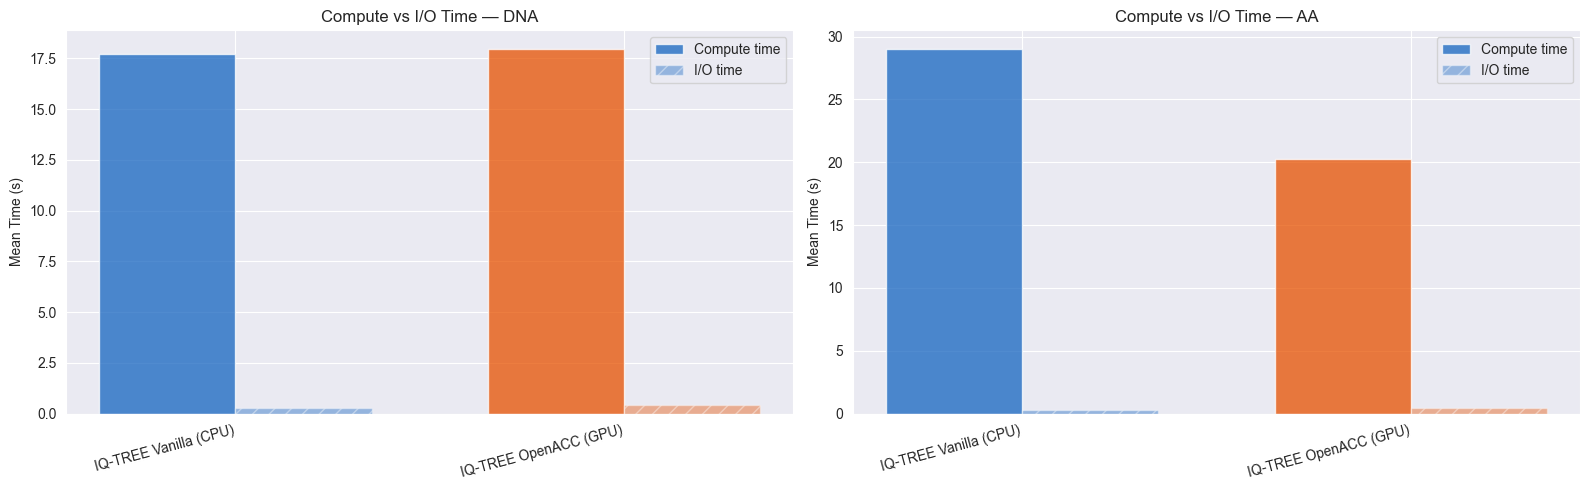

In [11]:
def plot_compute_breakdown(df_dna, df_aa, path=""):
    """Grouped bar: mean compute time vs mean I/O time per implementation."""
    implementations = ['VANILA', 'OPENACC']
    palette = {impl: IMPL_COLORS[impl] for impl in implementations}

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, df, label in zip(axes, [df_dna, df_aa], ['DNA', 'AA']):
        grp = df.groupby('implementation')[['compute_time_s', 'io_time_s']].mean()
        grp = grp.reindex(implementations)

        x = np.arange(len(implementations))
        w = 0.35
        ax.bar(x - w/2, grp['compute_time_s'], w, color=[IMPL_COLORS[i] for i in implementations],
               alpha=0.75, label='Compute time')
        ax.bar(x + w/2, grp['io_time_s'],      w, color=[IMPL_COLORS[i] for i in implementations],
               alpha=0.40, hatch='//', label='I/O time')

        ax.set_xticks(x)
        ax.set_xticklabels([IMPL_LABELS[i] for i in implementations], rotation=15, ha='right')
        ax.set_ylabel("Mean Time (s)")
        ax.set_title(f"Compute vs I/O Time — {label}")
        ax.legend()

    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()


plot_compute_breakdown(df_dna, df_aa, path=f"{cwd}/compute_io_breakdown.png")

---
## 8 · Energy vs Runtime Scatter  (efficiency view)

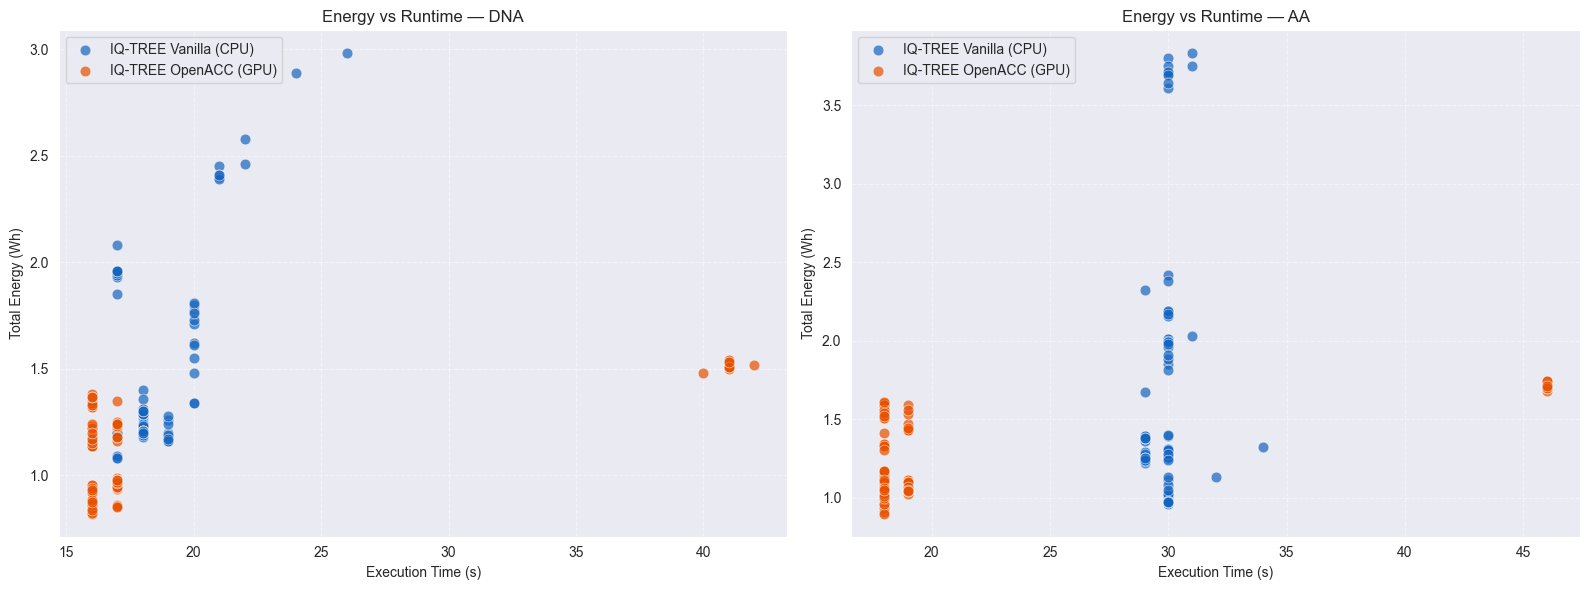

In [12]:
def plot_energy_vs_runtime(df_dna, df_aa, path=""):
    implementations = ['VANILA', 'OPENACC']
    palette = {impl: IMPL_COLORS[impl] for impl in implementations}

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, df, label in zip(axes, [df_dna, df_aa], ['DNA', 'AA']):
        for impl in implementations:
            sub = df[df['implementation'] == impl]
            ax.scatter(sub['total_time_s'], sub['total_energy_wh'],
                       c=IMPL_COLORS[impl], label=IMPL_LABELS[impl],
                       alpha=0.7, edgecolors='white', linewidths=0.5, s=60)

        ax.set_xlabel("Execution Time (s)")
        ax.set_ylabel("Total Energy (Wh)")
        ax.set_title(f"Energy vs Runtime — {label}")
        ax.legend(loc='upper left')
        ax.grid(True, ls='--', alpha=0.5)

    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()


plot_energy_vs_runtime(df_dna, df_aa, path=f"{cwd}/energy_vs_runtime_scatter.png")

---
## 9 · Speedup & Energy Savings (OpenACC vs Vanilla)

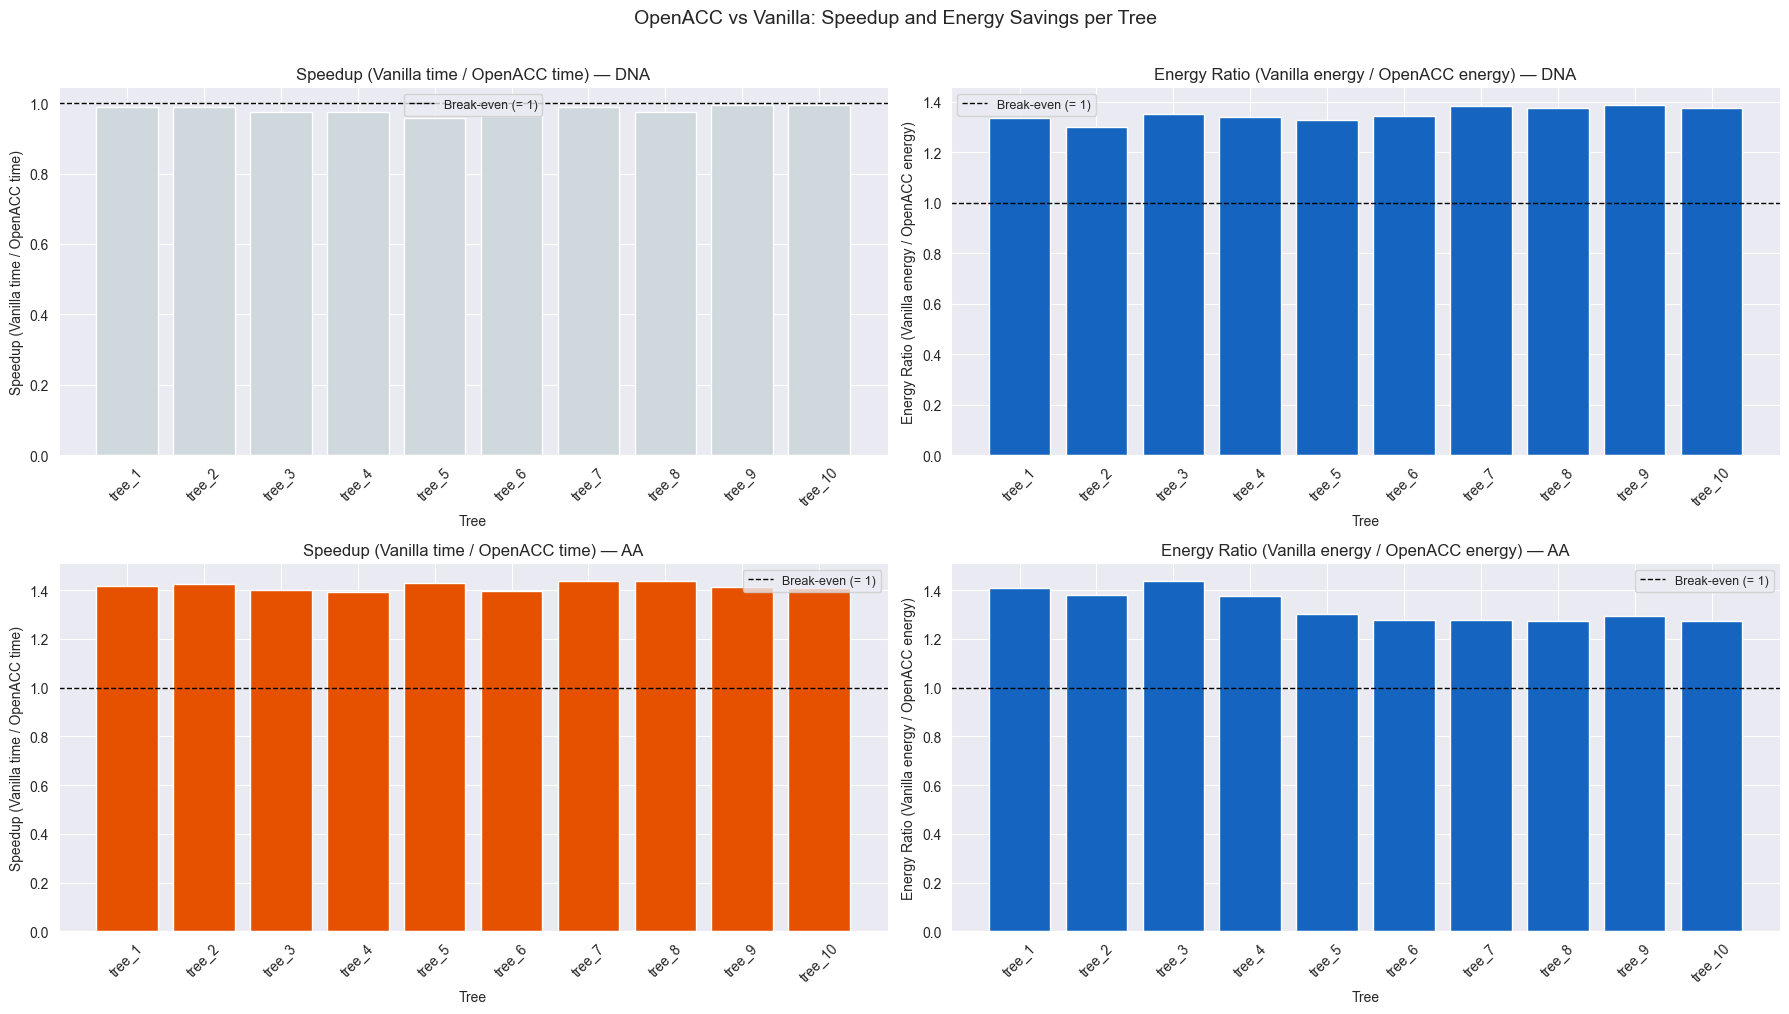


DNA — mean speedup: 0.980x  | mean energy ratio: 1.351x


,speedup,energy_saving
tree,,
tree_1,0.990,1.334
tree_2,0.989,1.299
tree_3,0.973,1.350
tree_4,0.973,1.340
tree_5,0.958,1.327
tree_6,0.963,1.343
tree_7,0.989,1.381
tree_8,0.973,1.374
tree_9,0.995,1.387



AA — mean speedup: 1.416x  | mean energy ratio: 1.330x


,speedup,energy_saving
tree,,
tree_1,1.417,1.406
tree_2,1.427,1.378
tree_3,1.401,1.437
tree_4,1.392,1.376
tree_5,1.431,1.301
tree_6,1.396,1.279
tree_7,1.436,1.277
tree_8,1.438,1.274
tree_9,1.414,1.295


In [13]:
def compute_ratios(df, groupby='tree'):
    """Return per-tree mean ratios: speedup (VANILA_time / OPENACC_time),
       energy ratio (VANILA_energy / OPENACC_energy)."""
    grp = df.groupby(['implementation', groupby])[['total_time_s', 'total_energy_wh']].mean().unstack(0)
    grp.columns = ['_'.join(c) for c in grp.columns]
    grp['speedup']       = grp['total_time_s_VANILA']   / grp['total_time_s_OPENACC']
    grp['energy_saving'] = grp['total_energy_wh_VANILA'] / grp['total_energy_wh_OPENACC']
    return grp


def plot_speedup(df_dna, df_aa, path=""):
    ratios_dna = compute_ratios(df_dna)
    ratios_aa  = compute_ratios(df_aa)
    tree_order = _natural_order(ratios_dna.index.tolist())

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))

    configs = [
        ('speedup',       'Speedup (Vanilla time / OpenACC time)',           '#E65100'),
        ('energy_saving', 'Energy Ratio (Vanilla energy / OpenACC energy)', '#1565C0'),
    ]

    for col, (metric, ylabel, color) in enumerate(configs):
        for row, (ratios, label) in enumerate([(ratios_dna, 'DNA'), (ratios_aa, 'AA')]):
            ax = axes[row][col]
            vals = ratios.reindex(tree_order)[metric]
            colors = [color if v >= 1 else '#CFD8DC' for v in vals]
            ax.bar(tree_order, vals, color=colors, edgecolor='white')
            ax.axhline(1.0, color='black', linewidth=1, linestyle='--', label='Break-even (= 1)')
            ax.set_title(f"{ylabel} — {label}")
            ax.set_xlabel("Tree")
            ax.set_ylabel(ylabel)
            ax.tick_params(axis='x', rotation=45)
            ax.legend(fontsize=9)

    plt.suptitle("OpenACC vs Vanilla: Speedup and Energy Savings per Tree",
                 fontsize=14, y=1.01)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()

    # Print summary table
    for ratios, label in [(ratios_dna, 'DNA'), (ratios_aa, 'AA')]:
        r = ratios.reindex(tree_order)[['speedup', 'energy_saving']]
        print(f"\n{label} — mean speedup: {r['speedup'].mean():.3f}x  "
              f"| mean energy ratio: {r['energy_saving'].mean():.3f}x")
        display(r.style.format("{:.3f}").bar(subset=['speedup', 'energy_saving'],
                                             color=['#E65100', '#1565C0'], vmin=0))


plot_speedup(df_dna, df_aa, path=f"{cwd}/speedup_energy_savings.png")

---
## 10 · CPU Instruction Mix (Scalar vs Vector ops)

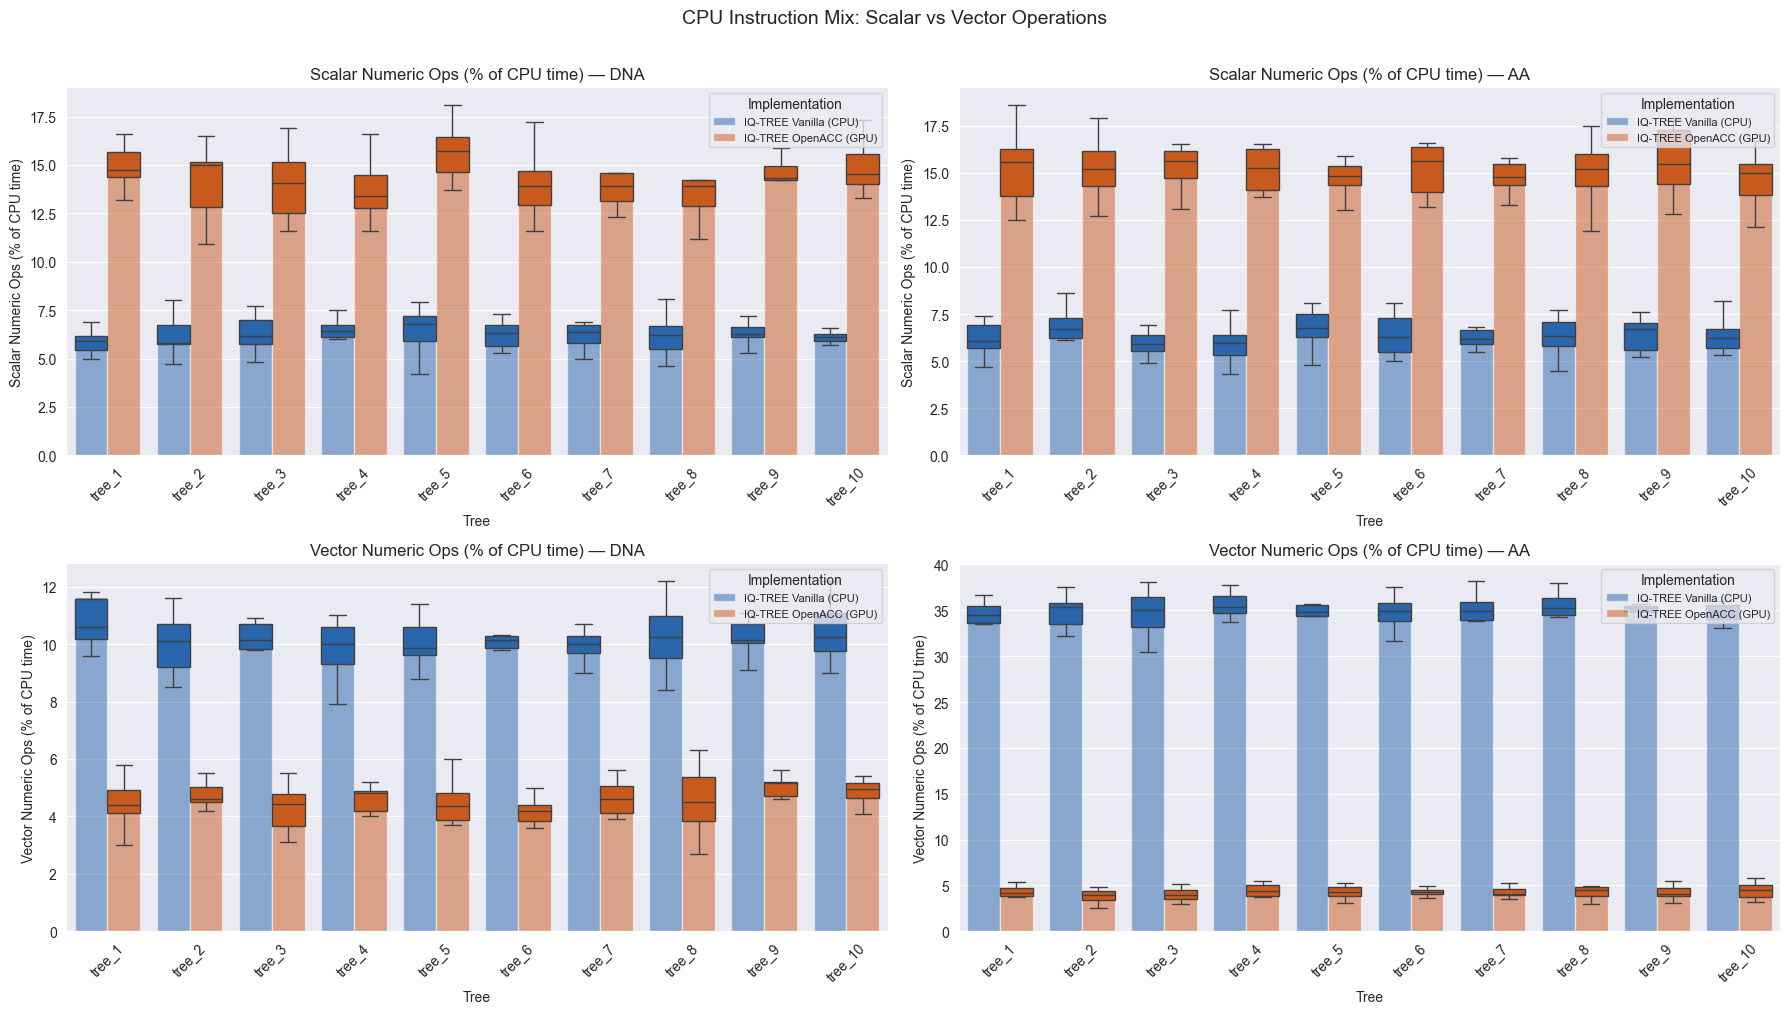

In [14]:
def plot_instruction_mix(df_dna, df_aa, path=""):
    implementations = ['VANILA', 'OPENACC']
    palette = {impl: IMPL_COLORS[impl] for impl in implementations}

    fig, axes = plt.subplots(2, 2, figsize=(18, 10))

    metrics = [
        ('scalar_ops_pct', 'Scalar Numeric Ops (% of CPU time)'),
        ('vector_ops_pct', 'Vector Numeric Ops (% of CPU time)'),
    ]
    datasets = [(df_dna, 'DNA'), (df_aa, 'AA')]
    tree_order = _natural_order(df_dna['tree'].unique())

    for row, (metric, ylabel) in enumerate(metrics):
        for col, (df, label) in enumerate(datasets):
            ax = axes[row][col]
            sns.barplot(data=df, x='tree', y=metric, hue='implementation',
                        order=tree_order, hue_order=implementations,
                        estimator='mean', errorbar=None, alpha=0.5,
                        dodge=True, palette=palette, ax=ax)
            sns.boxplot(data=df, x='tree', y=metric, hue='implementation',
                        order=tree_order, hue_order=implementations,
                        showfliers=False, linewidth=1, palette=palette, ax=ax)

            ax.set_title(f"{ylabel} — {label}")
            ax.set_xlabel("Tree")
            ax.set_ylabel(ylabel)
            ax.tick_params(axis='x', rotation=45)

            handles, labels_ = ax.get_legend_handles_labels()
            n = len(implementations)
            ax.legend(handles[:n], [IMPL_LABELS[l] for l in labels_[:n]],
                      title="Implementation", loc='upper right', fontsize=8)

    plt.suptitle("CPU Instruction Mix: Scalar vs Vector Operations", fontsize=14, y=1.01)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()


plot_instruction_mix(df_dna, df_aa, path=f"{cwd}/cpu_instruction_mix.png")

---
## 11 · Metric Heatmap Overview

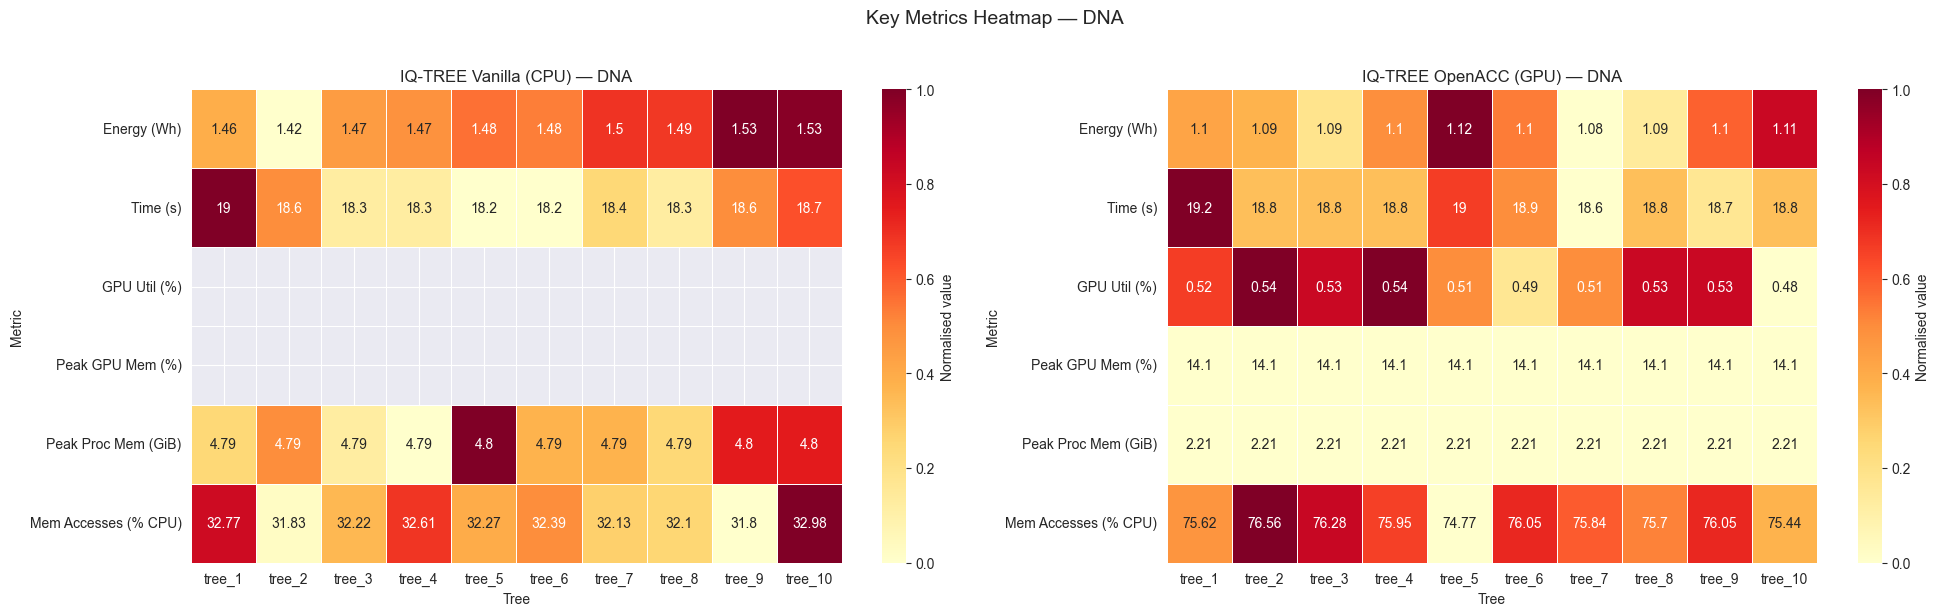

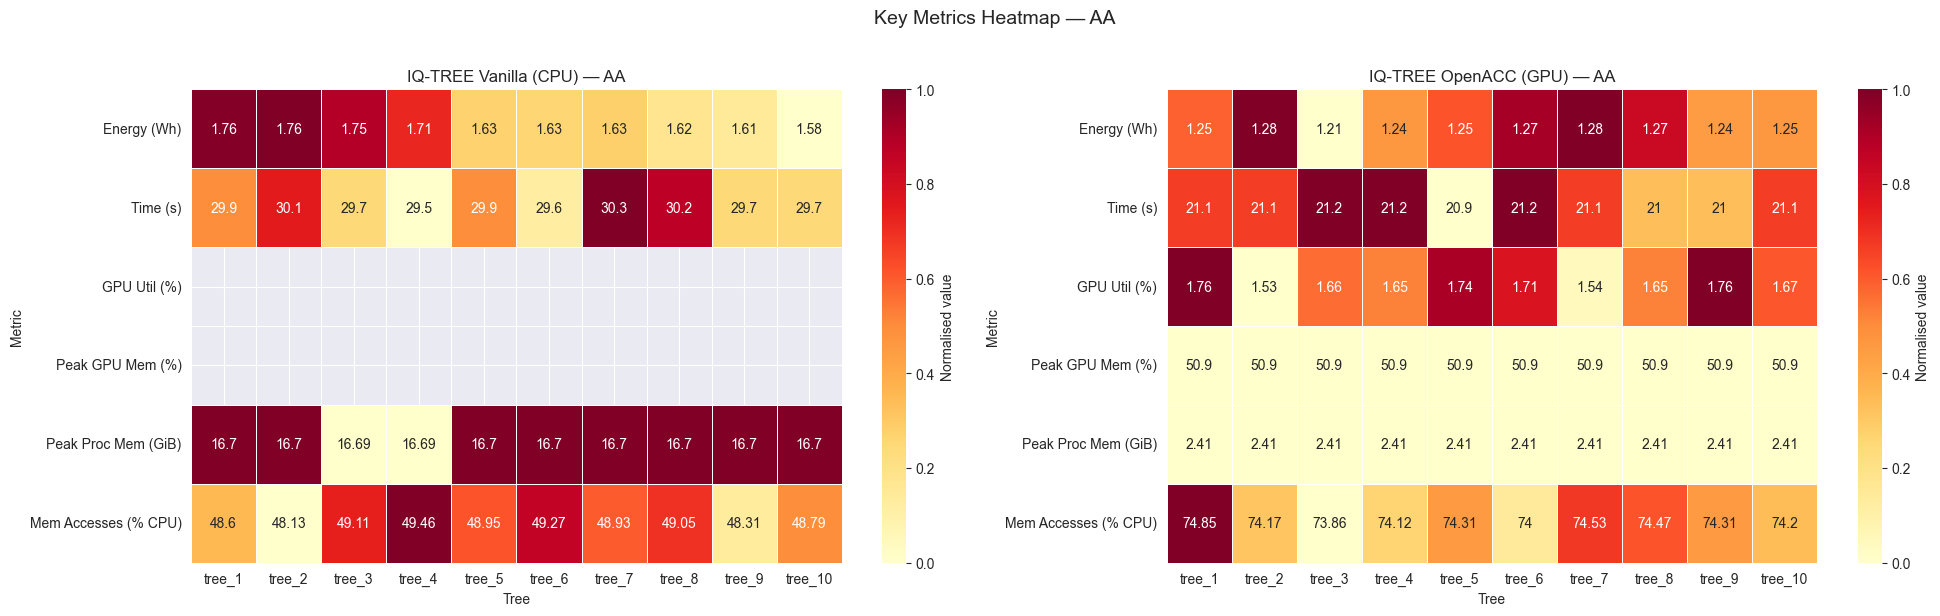

In [15]:
def plot_metric_heatmap(df, dataset_type, path=""):
    """Side-by-side heatmaps of key metrics, OPENACC vs VANILA, across trees."""
    tree_order = _natural_order(df['tree'].unique())
    HEAT_METRICS = {
        'total_energy_wh':   'Energy (Wh)',
        'total_time_s':      'Time (s)',
        'gpu_util_pct':      'GPU Util (%)',
        'gpu_mem_peak_pct':  'Peak GPU Mem (%)',
        'proc_mem_peak_gib': 'Peak Proc Mem (GiB)',
        'mem_accesses_pct':  'Mem Accesses (% CPU)',
    }

    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    for ax, impl in zip(axes, ['VANILA', 'OPENACC']):
        sub = df[df['implementation'] == impl]
        grp = sub.groupby('tree')[list(HEAT_METRICS.keys())].mean().reindex(tree_order)
        grp.columns = list(HEAT_METRICS.values())

        # Normalise each column 0-1 for heatmap colour scaling
        norm = (grp - grp.min()) / (grp.max() - grp.min() + 1e-12)

        sns.heatmap(norm.T, ax=ax, annot=grp.T.round(2), fmt='g',
                    cmap='YlOrRd', linewidths=0.5, cbar=True,
                    cbar_kws={'label': 'Normalised value'})
        ax.set_title(f"{IMPL_LABELS[impl]} — {dataset_type}")
        ax.set_xlabel("Tree")
        ax.set_ylabel("Metric")

    plt.suptitle(f"Key Metrics Heatmap — {dataset_type}", fontsize=14, y=1.02)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches='tight')
    plt.show()


plot_metric_heatmap(df_dna, 'DNA', path=f"{cwd}/heatmap_dna.png")
plot_metric_heatmap(df_aa,  'AA',  path=f"{cwd}/heatmap_aa.png")